# 1. Phase 2: Data Understanding & Profiling Specification

## 1.1 Objective & Scope
The objective of this phase is to perform a rigorous exploratory data analysis (EDA) and structural audit on the raw transactional log (`UCI Online Retail II`). 

By conducting deep data profiling prior to downstream feature engineering, we validate data integrity, identify domain-specific anomalies, quantify missingness, and assess how raw transaction dynamics align with our **Multi-Tier Churn Definition** established in Phase 1.

## 1.2 Data Understanding Taxonomy
Our analysis is structured around four primary analytical dimensions:

1. **Volume & Schema Audit:** Verifying record counts, data types, memory footprint, and primary/foreign key attributes.
2. **Missingness & Completeness Analysis:** Evaluating missing values (especially unassigned `Customer ID`s) and formulating business-driven imputation or exclusion rules.
3. **Data Integrity & Anomaly Detection:** Identifying negative quantities (returns/cancellation logs), zero/negative unit prices, test/administrative stock codes, and outlier distributions.
4. **Temporal Consistency & Seasonality:** Mapping the chronological coverage, identifying transaction gaps, and validating purchase intervals.

---

## 1.3 Schema Architecture Reference
The raw dataset comprises two operational years of retail transactions with the following schema specifications:

| Feature Name | Logical Data Type | Physical Type | Description & Domain Relevance |
| :--- | :--- | :--- | :--- |
| `Invoice` | Categorical / ID | `str` / `object` | 6-digit transaction identifier. Invoices prefixed with 'C' indicate cancellations. |
| `StockCode` | Categorical / ID | `str` / `object` | Stock keeping unit (SKU) identifier assigned to specific products/services. |
| `Description` | Text | `str` / `object` | Nominal item description. Contains dirty text, administrative noise, and missing values. |
| `Quantity` | Discrete Numeric | `int64` | Transaction line-item quantity per order line. Negative values denote returns/adjustments. |
| `InvoiceDate` | Temporal | `datetime64` | Timestamp of transaction creation (`YYYY-MM-DD HH:MM:SS`). |
| `Price` | Continuous Numeric | `float64` | Unit item price in GBP (£). Zero prices indicate gift items, promotional adjustments, or bad debt. |
| `Customer ID` | Categorical / ID | `float64` / `str` | Unique 5-digit customer identifier. Crucial for customer-level churn aggregation. |
| `Country` | Categorical | `str` / `object` | Geographic location of the customer/order destination. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set view options for professional profiling display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8-whitegrid')



## 1. 🔍 Data Architecture & Quality Overview

### 🎯 Objective:
Inspect the raw structural integrity of the dataset, assess schema completeness, and identify missing/duplicate record distribution before proceeding with downstream analytical pipelines.

### 📊 Key Diagnostic Observations:
* **Dataset Universe:** Total of **1,067,371 rows** spanning 8 core variables[cite: 5].
* **Customer Identification Gap:** **~22.76% (242,987 rows)** belong to **Guest Checkouts** (missing `Customer ID`)[cite: 5, 7]. These will be retained for total revenue & BI reporting but isolated during ML RFM segmentation[cite: 7].
* **Duplication Rate:** Identified **34,335 duplicate entries (3.22%)**, which require systematic deduplication during the cleaning phase to prevent artificial volume inflation[cite: 8].
* **Statistical Anomaly Detection:** Extracted negative minimum values in `Quantity` (-80,995) and `Price` (-£53,594.36), signalling returns, cancellations, and administrative adjustments[cite: 6].

In [2]:
RAW_DATA_PATH = Path(r"C:\Users\LOQ\OneDrive\Desktop\PROJECTS\PROGRAMMING\Customer Churn Intelligence & Retention System\data\raw\online_retail_II.xlsx")

sheet_one_df = pd.read_excel(RAW_DATA_PATH ,sheet_name = "Year 2009-2010")


In [3]:
sheet_one_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [4]:
sheet_two_df = pd.read_excel(RAW_DATA_PATH ,sheet_name = "Year 2010-2011")

In [5]:
sheet_two_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [6]:
whole_df = pd.concat([sheet_one_df, sheet_two_df], ignore_index=True)

In [ ]:
print(f"the information of the whole data :{whole_df.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB
the infomation of the whole data :None


In [8]:

print(f"\nthe description of the data:\n{whole_df.describe(include='all')}")


the description of the data:
           Invoice StockCode                         Description    Quantity  \
count  1067371.000   1067371                             1062989 1067371.000   
unique   53628.000      5305                                5698         NaN   
top     537434.000    85123A  WHITE HANGING HEART T-LIGHT HOLDER         NaN   
freq      1350.000      5829                                5918         NaN   
mean           NaN       NaN                                 NaN       9.939   
min            NaN       NaN                                 NaN  -80995.000   
25%            NaN       NaN                                 NaN       1.000   
50%            NaN       NaN                                 NaN       3.000   
75%            NaN       NaN                                 NaN      10.000   
max            NaN       NaN                                 NaN   80995.000   
std            NaN       NaN                                 NaN     172.706   

         

In [9]:
print(f"the number of null values is:\n{whole_df.isnull().sum()}")

the number of null values is:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


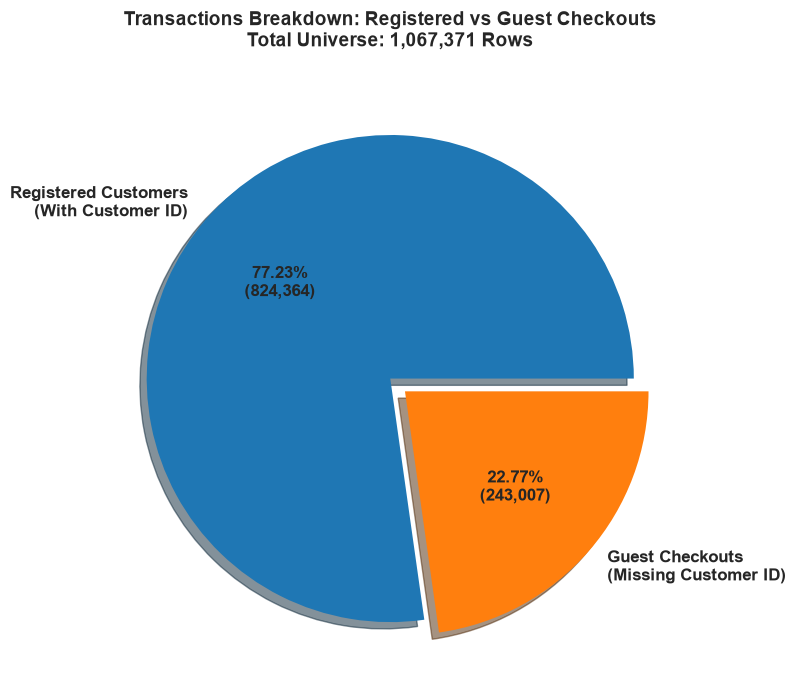

In [10]:
total_rows = len(whole_df)
guest_count = whole_df['Customer ID'].isnull().sum()
registered_count = total_rows - guest_count


labels = ['Registered Customers\n(With Customer ID)', 'Guest Checkouts\n(Missing Customer ID)']
sizes = [registered_count, guest_count]
colors = ['#1f77b4', '#ff7f0e']
explode = (0, 0.08)  

plt.figure(figsize=(8, 8))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    explode=explode,
    autopct=lambda pct: f"{pct:.2f}%\n({int(pct/100*total_rows):,})",
    textprops={'fontsize': 12, 'weight': 'bold'},
    shadow=True
)

plt.title(f"Transactions Breakdown: Registered vs Guest Checkouts\nTotal Universe: {total_rows:,} Rows", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [11]:
print(f"the number of duplicated values is : {whole_df.duplicated().sum()}")

the number of duplicated values is : 34335


the percentage of duplicated values is : 3.22%


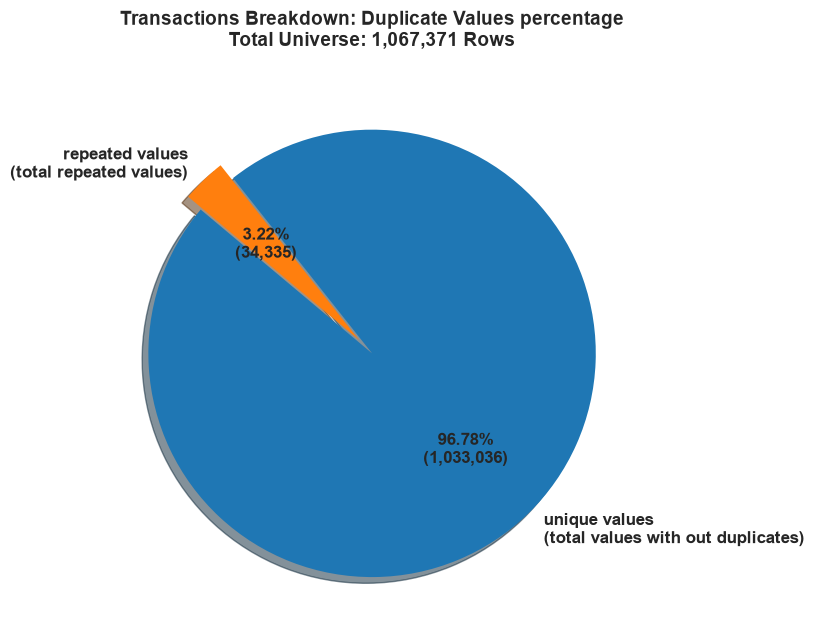

In [12]:
doplicate_persentage = (whole_df.duplicated().sum()/len(whole_df))*100
print(f"the percentage of duplicated values is : {doplicate_persentage:.2f}%")

labels = ['unique values \n(total values with out duplicates)', 'repeated values\n(total repeated values)']
sizes = [total_rows - whole_df.duplicated().sum(), whole_df.duplicated().sum()]
colors = ['#1f77b4', '#ff7f0e']
explode = (0, 0.08)  

plt.figure(figsize=(8, 8))
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    explode=explode,
    autopct=lambda pct: f"{pct:.2f}%\n({int(pct/100*total_rows):,})", 
    startangle=140,
    textprops={'fontsize': 12, 'weight': 'bold'},
    shadow=True
)

plt.title(f"Transactions Breakdown: Duplicate Values percentage\nTotal Universe: {total_rows:,} Rows", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 2. 🛠️ Data Preprocessing Baseline & Schema Standardization

### 🎯 Objective:
Create a standardized analytical dataframe (`df_profile`), enforce strict data typing across all fields, and derive feature-level metric aggregations (e.g., Gross Line Item Value).

### ⚙️ Transformation Steps Applied:
* **Type Casting:** Converted `Invoice` and `StockCode` to explicit strings[cite: 9]. Cast `Customer ID` to nullable integer `Int64` to preserve missingness integrity without float conversion issues[cite: 9].
* **Feature Engineering (`totalprice`):** Derived individual line-item value using $TotalPrice = Quantity \times Price$ to enable monetary metrics across both orders and cancellations[cite: 9].

In [13]:
df_profile = whole_df.copy()

df_profile['Invoice'] = df_profile['Invoice'].astype(str)
df_profile['Customer ID'] = df_profile['Customer ID'].astype('Int64')
df_profile['StockCode'] = df_profile['StockCode'].astype(str)
df_profile['Description'] = df_profile['Description'].astype(str)

df_profile['totalprice'] = df_profile['Quantity'] * df_profile['Price']

In [14]:
df_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   Int64         
 7   Country      1067371 non-null  str           
 8   totalprice   1067371 non-null  float64       
dtypes: Int64(1), datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 126.5 MB


## 3. 🌐 Geographic Distribution & Market Profiling

### 🎯 Objective:
Analyze the geographic distribution of transactions to understand market dominance and international reach.

### 📈 Geographic Insights:
* **Market Coverage:** Operations span across **43 unique countries**[cite: 10].
* **Core Market Dominance:** The **United Kingdom** represents the overwhelming majority of transaction volume (**981,330 rows ~91.9%**)[cite: 10].
* **Secondary Markets:** EIRE (Ireland), Germany, and France constitute the largest secondary international footprint[cite: 10].

In [15]:
country_number = df_profile['Country'].nunique()
print(f"the number of unique countries is :{country_number}")
df_profile['Country'].value_counts()

the number of unique countries is :43


Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               3189
Belgium                   3123
Portugal                  2620
Australia                 1913
Channel Islands           1664
Italy                     1534
Norway                    1455
Sweden                    1364
Cyprus                    1176
Finland                   1049
Austria                    938
Denmark                    817
Unspecified                756
Greece                     663
Japan                      582
USA                        535
Poland                     535
United Arab Emirates       500
Israel                     371
Hong Kong                  364
Singapore                  346
Malta                      299
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        169


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\507435674.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


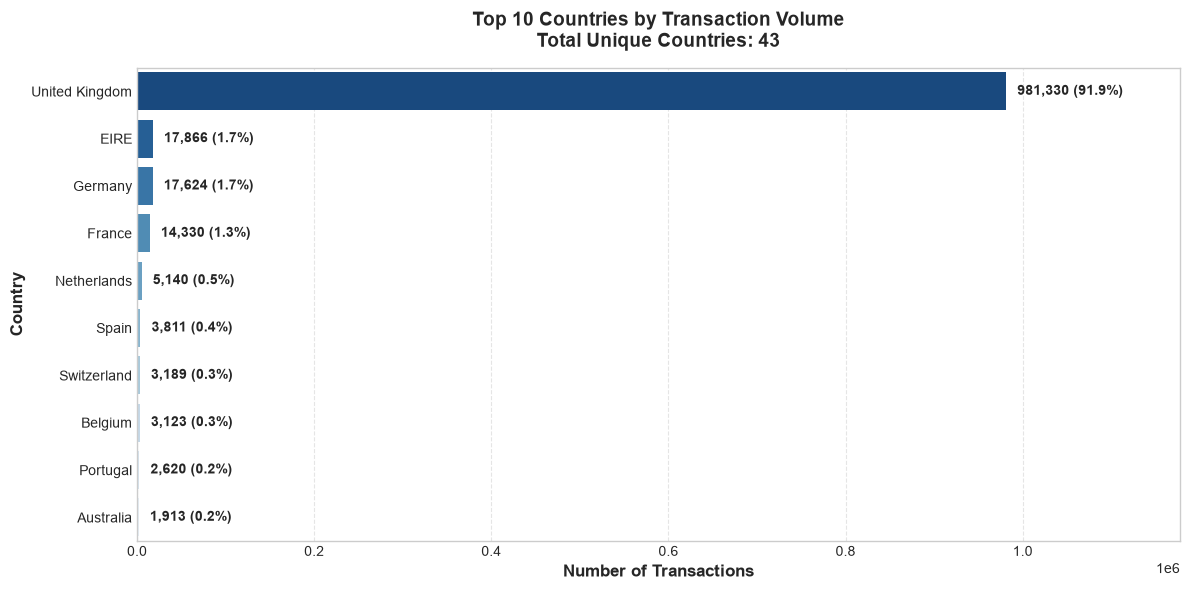

In [16]:
top_countries = df_profile['Country'].value_counts().head(10)


plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    palette='Blues_r'
)


total_transactions = len(df_profile)

for p in ax.patches:
    width = p.get_width()
    percentage = (width / total_transactions) * 100
    ax.annotate(
        f'{int(width):,} ({percentage:.1f}%)', 
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', 
        va='center', 
        xytext=(8, 0), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )


plt.title(f'Top 10 Countries by Transaction Volume\nTotal Unique Countries: {df_profile["Country"].nunique()}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Transactions', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')


plt.xlim(0, top_countries.values[0] * 1.2)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

import plotly.express as px

country_counts = df_profile['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Transaction_Count']

fig = px.bar(
    country_counts, 
    x='Transaction_Count', 
    y='Country', 
    orientation='h',
    log_x=True,  
    title=f'Transaction Distribution Across All {df_profile["Country"].nunique()} Countries (Log Scale)',
    labels={'Transaction_Count': 'Transaction Count (Log Scale)', 'Country': 'Country'},
    color='Transaction_Count',
    color_continuous_scale='Blues'
)

fig.update_layout(yaxis={'categoryorder':'total ascending'}, height=900)
fig.show()

## 4. ⚖️ Transactional Integrity & Operational SKUs Audit

### 🎯 Objective:
Isolate non-standard transaction mechanisms — specifically Canceled Invoices ('C') and Non-Product/Administrative SKUs — to accurately reconcile Gross vs. Net Revenue.

### 🔍 Financial & Audit Findings:
* **Cancellation Impact ('C' Invoices):**
  * **Cancellation Records:** **19,494 rows (1.83%)** represent transaction cancellations/returns[cite: 13].
  * **Revenue Drag:** Cancellation values account for **£1,526,667.86**, representing a **7.33% Net Revenue Impact Ratio** against Gross Sales (£20,813,918.43)[cite: 13].
* **Administrative & Non-Product SKUs:**
  * **Non-Catalog Items Identified:** Isolated non-inventory codes including `POST` (Postage), `M` (Manual), `D` (Discount), `BANK CHARGES`, and `AMAZONFEE`[cite: 14].
  * **Volume & Value:** Identified **5,517 admin records (0.52%)** generating **£35,180.83**[cite: 14].

In [17]:
cancellation_mask = df_profile['Invoice'].str.startswith('C', na=False)

df_cancels = df_profile[cancellation_mask].copy()
df_valid = df_profile[~cancellation_mask].copy()

df_cancels.value_counts(subset=['Invoice'])


Invoice
C570867    101
C560540     57
C524235     45
C548460     45
C536164     44
          ... 
C581463      1
C581470      1
C581484      1
C581499      1
C581568      1
Name: count, Length: 8292, dtype: int64

In [18]:
df_valid.value_counts(subset=['Invoice'])

Invoice
537434     1350
538071     1304
537638     1202
537237     1194
536876     1186
           ... 
581479        1
581483        1
581487        1
581491        1
581566        1
Name: count, Length: 45336, dtype: int64

C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\1851059041.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_valid.values, y=top_valid.index.astype(str), ax=axes[0], palette='Blues_r')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\1851059041.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cancels.values, y=top_cancels.index.astype(str), ax=axes[1], palette='Reds_r')


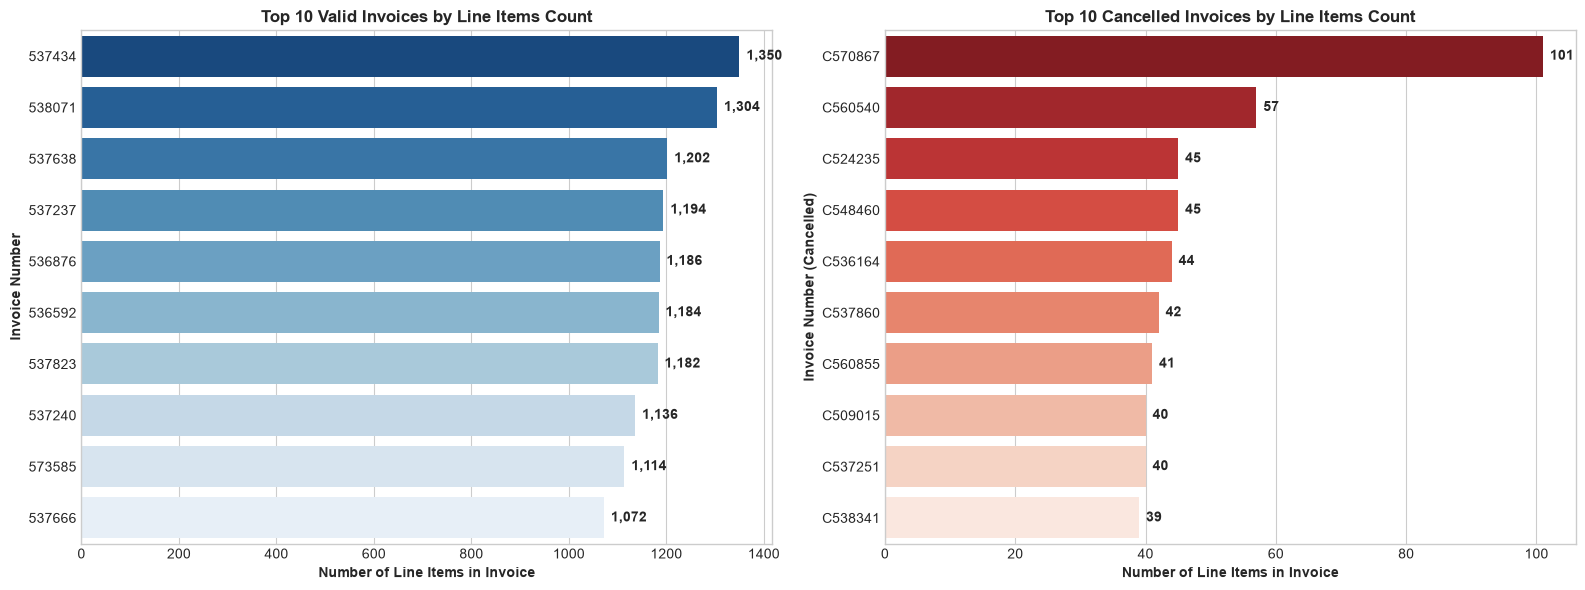

In [19]:
top_cancels = df_cancels['Invoice'].value_counts().head(10)
top_valid = df_valid['Invoice'].value_counts().head(10)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.barplot(x=top_valid.values, y=top_valid.index.astype(str), ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Valid Invoices by Line Items Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Line Items in Invoice', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Invoice Number', fontsize=10, fontweight='bold')

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')


sns.barplot(x=top_cancels.values, y=top_cancels.index.astype(str), ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Cancelled Invoices by Line Items Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Line Items in Invoice', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Invoice Number (Cancelled)', fontsize=10, fontweight='bold')

for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
total_gross_revenue = df_valid['totalprice'].sum()
total_cancellation_value = df_cancels['totalprice'].sum().__abs__()
total_net_revenue = total_gross_revenue - total_cancellation_value

print(f"the total gross revenue is : {total_gross_revenue}")
print(f"the total cancellation value is : {total_cancellation_value}")
print(f"the total net revenue is : {total_net_revenue}")

the total gross revenue is : 20813918.428
the total cancellation value is : 1526667.86
the total net revenue is : 19287250.568


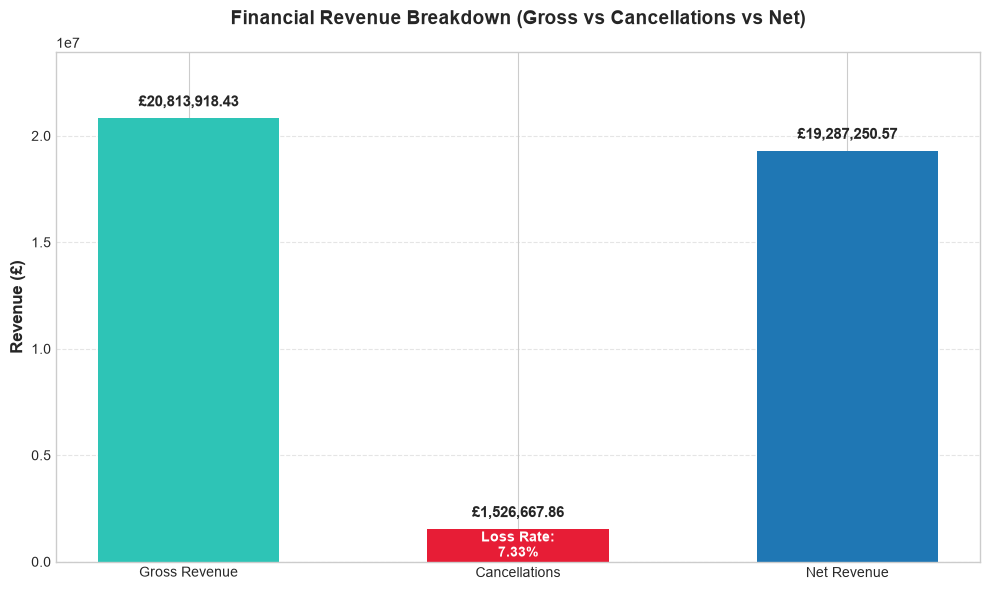

In [21]:
gross = df_valid['totalprice'].sum()
cancels = abs(df_cancels['totalprice'].sum())
net = gross - cancels
cancel_pct = (cancels / gross) * 100

categories = ['Gross Revenue', 'Cancellations', 'Net Revenue']
values = [gross, cancels, net]
colors = ['#2ec4b6', '#e71d36', '#1f77b4']


plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors, width=0.55)


for bar, val in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + (gross * 0.02), 
        f"£{val:,.2f}", 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold'
    )


plt.text(1, cancels/2, f"Loss Rate:\n{cancel_pct:.2f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=10)


plt.title("Financial Revenue Breakdown (Gross vs Cancellations vs Net)", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Revenue (£)", fontsize=12, fontweight='bold')
plt.ylim(0, gross * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
print("=== 1. CANCELLATION & RETURN AUDIT ===")
print(f"• Valid Transaction Rows:     {len(df_valid):,} ({len(df_valid)/len(df_profile)*100:.2f}%)")
print(f"• Cancellation Transaction Rows: {len(df_cancels):,} ({len(df_cancels)/len(df_profile)*100:.2f}%)")
print(f"• Gross Revenue (Valid):       £{total_gross_revenue:,.2f}")
print(f"• Total Value of Returns ('C'): £{total_cancellation_value:,.2f}")
print(f"• Net Revenue Impact Ratio:    {(abs(total_cancellation_value)/total_gross_revenue)*100:.2f}%")

=== 1. CANCELLATION & RETURN AUDIT ===
• Valid Transaction Rows:     1,047,877 (98.17%)
• Cancellation Transaction Rows: 19,494 (1.83%)
• Gross Revenue (Valid):       £20,813,918.43
• Total Value of Returns ('C'): £1,526,667.86
• Net Revenue Impact Ratio:    7.33%


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\2963000385.py:64: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


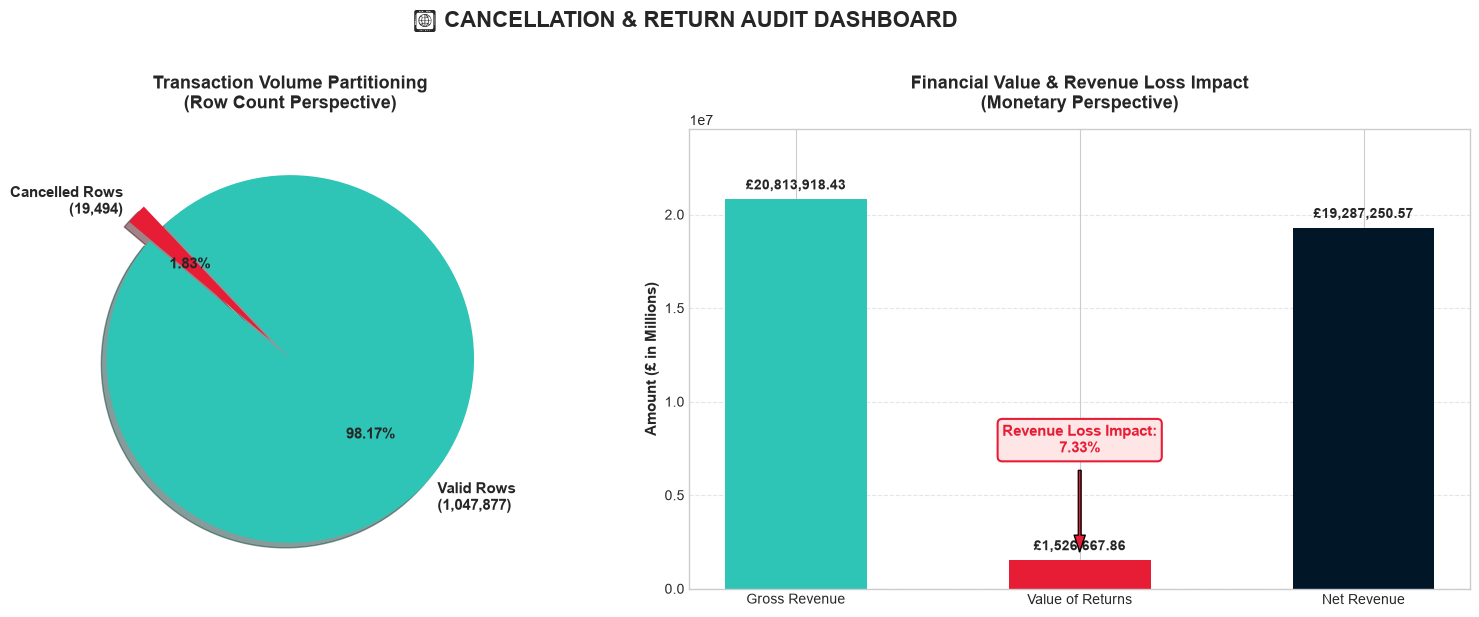

In [23]:
valid_rows = len(df_valid)
cancel_rows = len(df_cancels)
total_rows = len(df_profile)

gross_rev = total_gross_revenue
cancel_val = abs(total_cancellation_value)
net_rev = gross_rev - cancel_val
impact_ratio = (cancel_val / gross_rev) * 100


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("📌 CANCELLATION & RETURN AUDIT DASHBOARD", fontsize=16, fontweight='bold', y=1.02)


sizes_rows = [valid_rows, cancel_rows]
labels_rows = [f'Valid Rows\n({valid_rows:,})', f'Cancelled Rows\n({cancel_rows:,})']
colors_rows = ['#2ec4b6', '#e71d36']

axes[0].pie(
    sizes_rows, 
    labels=labels_rows, 
    colors=colors_rows, 
    explode=(0, 0.15), 
    autopct='%1.2f%%',
    startangle=140,
    textprops={'fontsize': 11, 'weight': 'bold'},
    shadow=True
)
axes[0].set_title("Transaction Volume Partitioning\n(Row Count Perspective)", fontsize=13, fontweight='bold', pad=15)


categories = ['Gross Revenue', 'Value of Returns', 'Net Revenue']
values = [gross_rev, cancel_val, net_rev]
colors_financial = ['#2ec4b6', '#e71d36', '#011627']

bars = axes[1].bar(categories, values, color=colors_financial, width=0.5)


for bar, val in zip(bars, values):
    yval = bar.get_height()
    axes[1].annotate(
        f"£{val:,.2f}",
        (bar.get_x() + bar.get_width() / 2.0, yval),
        ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        fontsize=10, fontweight='bold'
    )


axes[1].annotate(
    f"Revenue Loss Impact:\n{impact_ratio:.2f}%",
    xy=(1, cancel_val),
    xytext=(1, gross_rev * 0.35),
    arrowprops=dict(facecolor='#e71d36', shrink=0.08, width=2, headwidth=8),
    ha='center', fontweight='bold', color='#e71d36', fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="#ffe6e6", ec="#e71d36", lw=1.5)
)

axes[1].set_title("Financial Value & Revenue Loss Impact\n(Monetary Perspective)", fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel("Amount (£ in Millions)", fontsize=11, fontweight='bold')
axes[1].set_ylim(0, gross_rev * 1.18)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [24]:
admin_codes = ['POST', 'PADS', 'M', 'D', 'DOT', 'BANK CHARGES', 'S', 'AMAZONFEE', 'CRUK', 'TEST', 'ADJUST']
admin_mask = df_profile['StockCode'].astype(str).isin(admin_codes)

print("\n=== 2. ADMINISTRATIVE & NON-PRODUCT SKUs AUDIT ===")
print(f"• Total Admin Records:        {admin_mask.sum():,} ({admin_mask.sum()/len(df_profile)*100:.2f}%)")
print(f"• Admin Records Revenue:      £{df_profile[admin_mask]['totalprice'].sum():,.2f}")


=== 2. ADMINISTRATIVE & NON-PRODUCT SKUs AUDIT ===
• Total Admin Records:        5,517 (0.52%)
• Admin Records Revenue:      £35,180.83


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\515726920.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=admin_summary, x='Total_Revenue', y='StockCode', ax=axes[0], palette='Reds_r')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\515726920.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=admin_summary, x='Count', y='StockCode', ax=axes[1], palette='Blues_r')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\515726920.py:36: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_fig

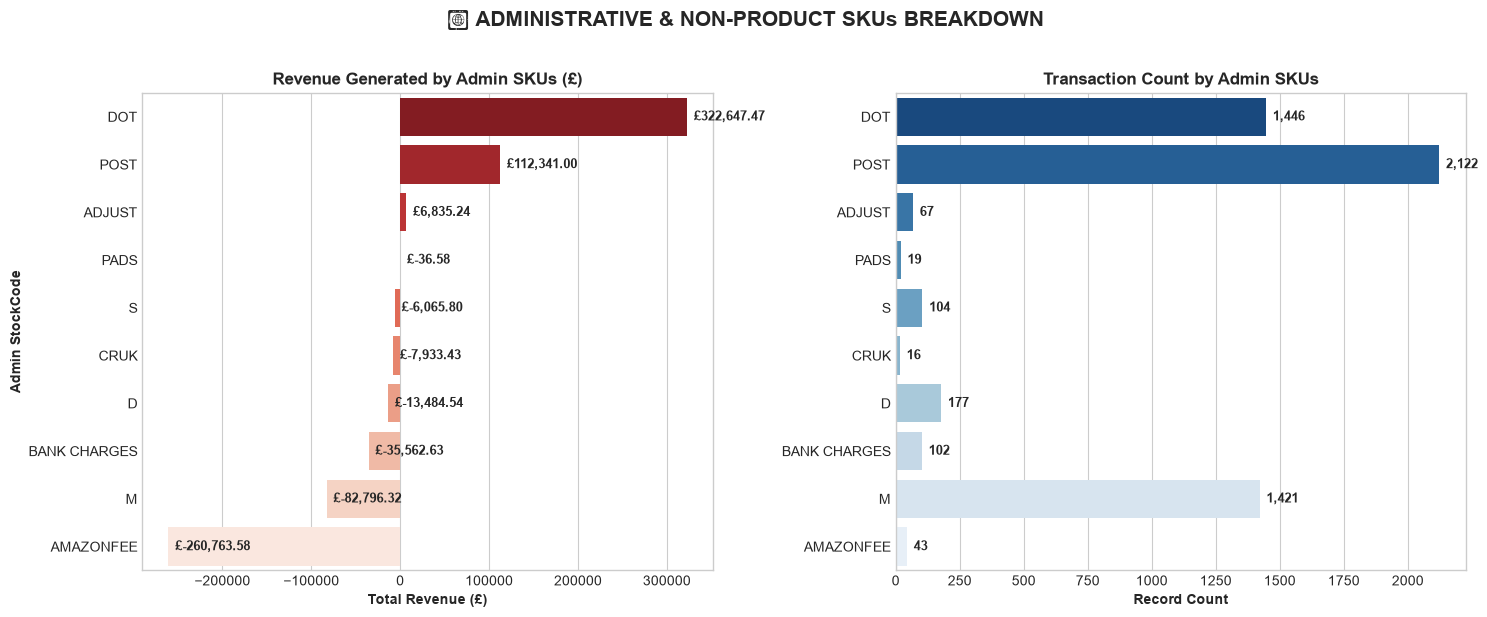

In [25]:
admin_df = df_profile[admin_mask].copy()


admin_summary = admin_df.groupby('StockCode').agg(
    Count=('StockCode', 'count'),
    Total_Revenue=('totalprice', 'sum')
).reset_index().sort_values(by='Total_Revenue', ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("📌 ADMINISTRATIVE & NON-PRODUCT SKUs BREAKDOWN", fontsize=15, fontweight='bold', y=1.02)


sns.barplot(data=admin_summary, x='Total_Revenue', y='StockCode', ax=axes[0], palette='Reds_r')
axes[0].set_title('Revenue Generated by Admin SKUs (£)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Admin StockCode', fontsize=10, fontweight='bold')

for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'£{width:,.2f}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold', fontsize=9)


sns.barplot(data=admin_summary, x='Count', y='StockCode', ax=axes[1], palette='Blues_r')
axes[1].set_title('Transaction Count by Admin SKUs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Record Count', fontsize=10, fontweight='bold')
axes[1].set_ylabel('', fontsize=10)


for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 5. 👥 Customer Type Profiling & Advanced Statistical Volatility Audit

### 🎯 Objective:
Evaluate revenue contribution across customer authentication states (Registered vs Guest) and conduct non-parametric statistical analysis using NumPy to evaluate order value skewness and bulk purchasing behavior.

### 📊 Key Diagnostic & Financial Insights:
* **Customer Authentication Split:**
  * **Registered Customers:** Represent **77.23% (824,364 rows)** of traffic and drive **85.25% (£17,743,429.18)** of total gross sales[cite: 15].
  * **Guest Checkouts:** Represent **22.77% (243,007 rows)** of transactions, driving **14.75% (£3,070,489.25)** of sales[cite: 15].
* **Statistical Distribution & Volatility Metrics:**
  * **Median vs Mean:** Median order value sits at **£9.95**, highlighting severe right-skewness compared to standard arithmetic averages[cite: 16].
  * **Standard Deviation (Volatility):** High dispersion at **£217.47**, driven by heavy bulk wholesale buyers[cite: 16].
  * **Outliers & Bulk Purchases:** The **99th percentile threshold is £183.60**[cite: 16]. Isolated **85,712 high-value / bulk order lines** using IQR bounds ($Q3 + 1.5 \times IQR$)[cite: 16].
  * **Feature Transformation:** Applied Log-transformation ($\log1p$) to normalize order value distributions for downstream ML pipelines[cite: 16].

In [26]:
guest_mask = df_profile['Customer ID'].isnull()

registered_revenue = df_valid[~df_valid['Customer ID'].isnull()]['totalprice'].sum()
guest_revenue = df_valid[df_valid['Customer ID'].isnull()]['totalprice'].sum()

In [27]:
print("=== GUEST CHECKOUT VS REGISTERED CUSTOMER PROFILING ===")
print(f"• Registered Customer Rows: { (~guest_mask).sum():,} ({(~guest_mask).sum()/len(df_profile)*100:.2f}%)")
print(f"• Guest Checkout Rows:      { guest_mask.sum():,} ({guest_mask.sum()/len(df_profile)*100:.2f}%)")
print(f"• Revenue from Registered:  £{registered_revenue:,.2f} ({(registered_revenue/total_gross_revenue)*100:.2f}%)")
print(f"• Revenue from Guests:      £{guest_revenue:,.2f} ({(guest_revenue/total_gross_revenue)*100:.2f}%)")

=== GUEST CHECKOUT VS REGISTERED CUSTOMER PROFILING ===
• Registered Customer Rows: 824,364 (77.23%)
• Guest Checkout Rows:      243,007 (22.77%)
• Revenue from Registered:  £17,743,429.18 (85.25%)
• Revenue from Guests:      £3,070,489.25 (14.75%)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\3409776429.py:39: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()


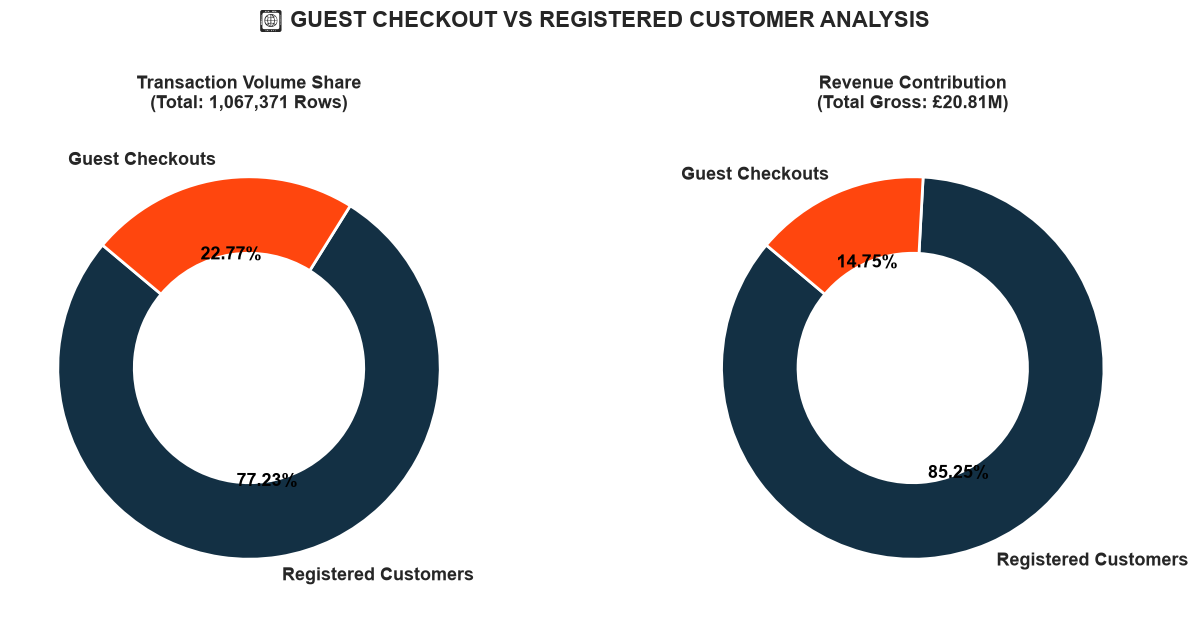

In [28]:
categories = ['Registered Customers', 'Guest Checkouts']
rows = [824364, 243007]
revenue = [17743429.18, 3070489.25]
colors = ["#133044", "#ff460e"] 


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("📌 GUEST CHECKOUT VS REGISTERED CUSTOMER ANALYSIS", fontsize=16, fontweight='bold', y=1.02)


wedges1, texts1, autotexts1 = axes[0].pie(
    rows, 
    labels=categories, 
    autopct='%1.2f%%',
    startangle=140, 
    colors=colors, 
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 13, 'weight': 'bold'}
)
axes[0].set_title("Transaction Volume Share\n(Total: 1,067,371 Rows)", fontsize=13, fontweight='bold', pad=15)


wedges2, texts2, autotexts2 = axes[1].pie(
    revenue, 
    labels=categories, 
    autopct='%1.2f%%',
    startangle=140, 
    colors=colors, 
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 13, 'weight': 'bold'}
)
axes[1].set_title("Revenue Contribution\n(Total Gross: £20.81M)", fontsize=13, fontweight='bold', pad=15)


for autotext in autotexts1 + autotexts2:
    autotext.set_color('black')
    autotext.set_weight('bold')

plt.tight_layout()
plt.show()

In [29]:
q25, q75 = np.percentile(df_valid['totalprice'], [25, 75])
iqr = q75 - q25
upper_bound = q75 + (1.5 * iqr)
lower_bound = q25 - (1.5 * iqr)

In [30]:
df_valid['is_high_value'] = np.where(df_valid['totalprice'] > upper_bound, 'High Value / Bulk', 'Normal')
df_valid['log_totalprice'] = np.log1p(np.maximum(0, df_valid['totalprice']))

print("=== ADVANCED STATISTICAL AUDIT (NUMPY INTEGRATION) ===")
print(f"• Median Revenue per Order (NumPy): £{np.median(df_valid['totalprice']):.2f}")
print(f"• Standard Deviation (Volatility):  £{np.std(df_valid['totalprice']):.2f}")
print(f"• 99th Percentile Order Value:     £{np.percentile(df_valid['totalprice'], 99):.2f}")
print(f"• Total High Value / Bulk Orders:   {(df_valid['is_high_value'] == 'High Value / Bulk').sum():,}")

=== ADVANCED STATISTICAL AUDIT (NUMPY INTEGRATION) ===
• Median Revenue per Order (NumPy): £9.95
• Standard Deviation (Volatility):  £217.47
• 99th Percentile Order Value:     £183.60
• Total High Value / Bulk Orders:   85,712


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\1848830456.py:16: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


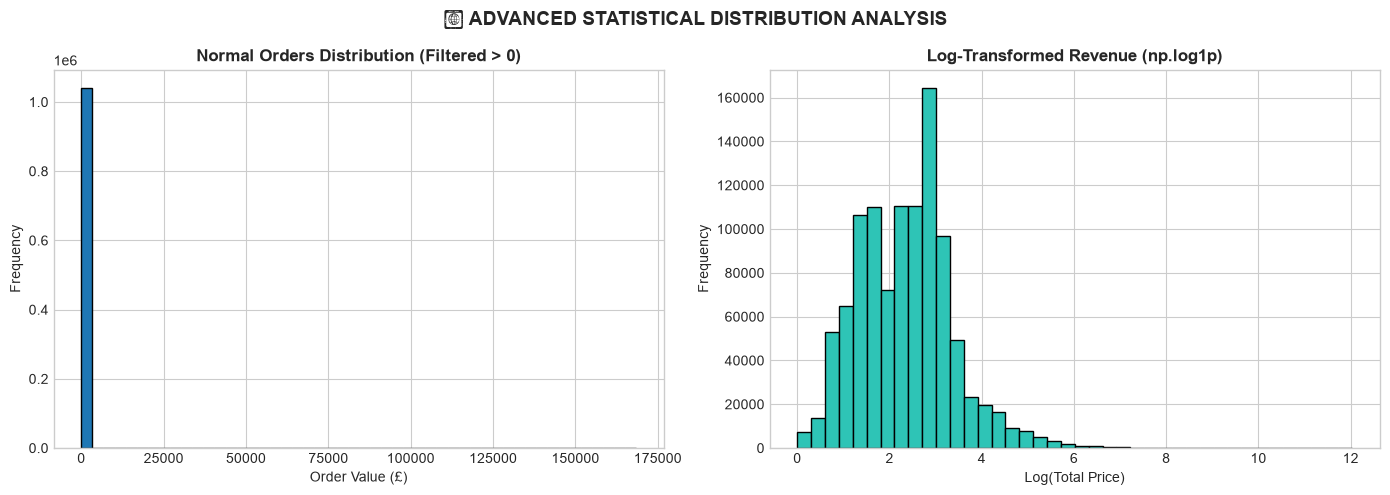

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📌 ADVANCED STATISTICAL DISTRIBUTION ANALYSIS", fontsize=14, fontweight='bold')



axes[0].hist(df_valid[df_valid['totalprice'] > 0]['totalprice'], bins=50, color='#1f77b4', edgecolor='black')
axes[0].set_title("Normal Orders Distribution (Filtered > 0)", fontweight='bold')
axes[0].set_xlabel("Order Value (£)")
axes[0].set_ylabel("Frequency")

axes[1].hist(df_valid['log_totalprice'], bins=40, color='#2ec4b6', edgecolor='black')
axes[1].set_title("Log-Transformed Revenue (np.log1p)", fontweight='bold')
axes[1].set_xlabel("Log(Total Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 6. 📦 Catalog Concentration & Pareto (80/20) Revenue Analysis

### 🎯 Objective:
Assess revenue concentration across unique product SKUs using the Pareto Principle ($80/20$ Rule) to identify core catalog revenue drivers vs operational return risks.

### 📈 Product Performance Findings:
* **Pareto Concentration Ratio:** Evaluated cumulative product sales to calculate the percentage of SKUs generating 80% of total revenue[cite: 17].
* **Top Revenue vs Return Isolation:** Mapped top revenue-generating items against top cancelled product units to untangle product popularity from potential product defects or quality issues[cite: 17].

=== 📊 PARETO ANALYSIS (80/20 RULE) ===
• Total Unique Products: 5,682
• Top 1,109 products (19.52%) generate 80% of total revenue!


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\3034792300.py:61: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\3034792300.py:61: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


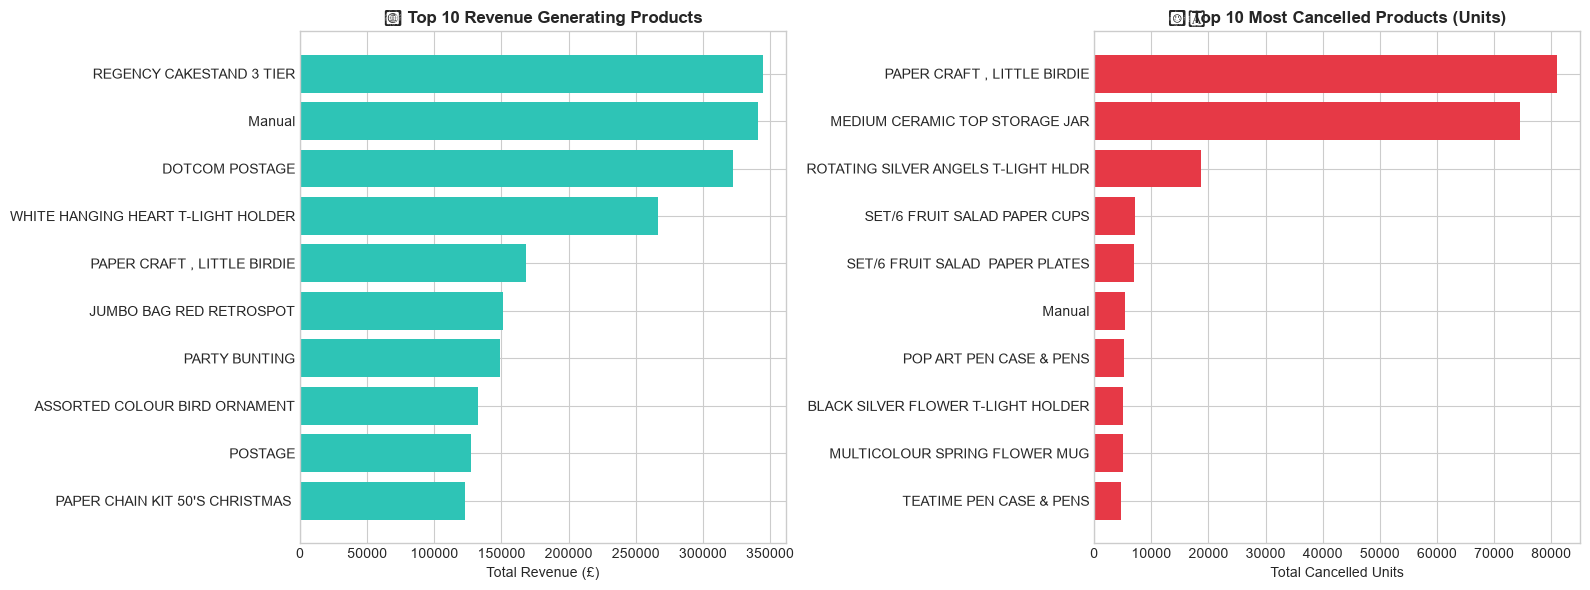

In [32]:
# تأكيد وجود عمود TotalPrice
if 'totalprice' in df_valid.columns:
    df_valid['TotalPrice'] = df_valid['totalprice']
elif 'TotalPrice' not in df_valid.columns:
    df_valid['TotalPrice'] = df_valid['Quantity'] * df_valid['Price']

# --- A. Pareto Analysis (80/20 Rule) ---
product_sales = (
    df_valid.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
product_sales['Cumulative_Revenue'] = product_sales['TotalPrice'].cumsum()
total_revenue = product_sales['TotalPrice'].sum()
product_sales['Cumulative_Percentage'] = (
    product_sales['Cumulative_Revenue'] / total_revenue
) * 100

# نسبة المنتجات التي تحقق 80% من المبيعات
products_80_percent = product_sales[
    product_sales['Cumulative_Percentage'] <= 80
]
pct_products_needed = (len(products_80_percent) / len(product_sales)) * 100

print("=== 📊 PARETO ANALYSIS (80/20 RULE) ===")
print(f"• Total Unique Products: {len(product_sales):,}")
print(
    f"• Top {len(products_80_percent):,} products ({pct_products_needed:.2f}%) generate 80% of total revenue!"
)

# --- B. Top 10 Products by Revenue & Top 10 Cancellations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top 10 Revenue Products
top_10_revenue = product_sales.head(10)
axes[0].barh(
    top_10_revenue['Description'],
    top_10_revenue['TotalPrice'],
    color='#2ec4b6',
)
axes[0].set_title('🔥 Top 10 Revenue Generating Products', fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].invert_yaxis()

# 2. Top 10 Cancelled Products
top_10_cancelled = (
    df_cancels.groupby('Description')['Quantity']
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
axes[1].barh(
    top_10_cancelled.index, top_10_cancelled.values, color='#e63946'
)
axes[1].set_title('⚠️ Top 10 Most Cancelled Products (Units)', fontweight='bold')
axes[1].set_xlabel('Total Cancelled Units')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. ⏰ Temporal Demand Profiling & Operational Peak Windows

### 🎯 Objective:
Extract time-series components (Hour of day, Day of week) to map purchasing seasonality, peak operational checkout windows, and low-activity periods[cite: 18].

### 🕒 Time-Series Insights:
* **Peak Ordering Hours:** Order volume peaks at **12:00 PM (7,056 Invoices)**, indicating mid-day checkout concentration[cite: 19].
* **Lowest Activity Windows:** Inactive / lowest checkout volume recorded around **6:00 AM (1 Invoice)**[cite: 19].
* **Busiest Day of Week:** **Thursday** accounts for maximum weekly order volume (**9,313 Invoices**)[cite: 19].

C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\1327420685.py:52: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\1327420685.py:52: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


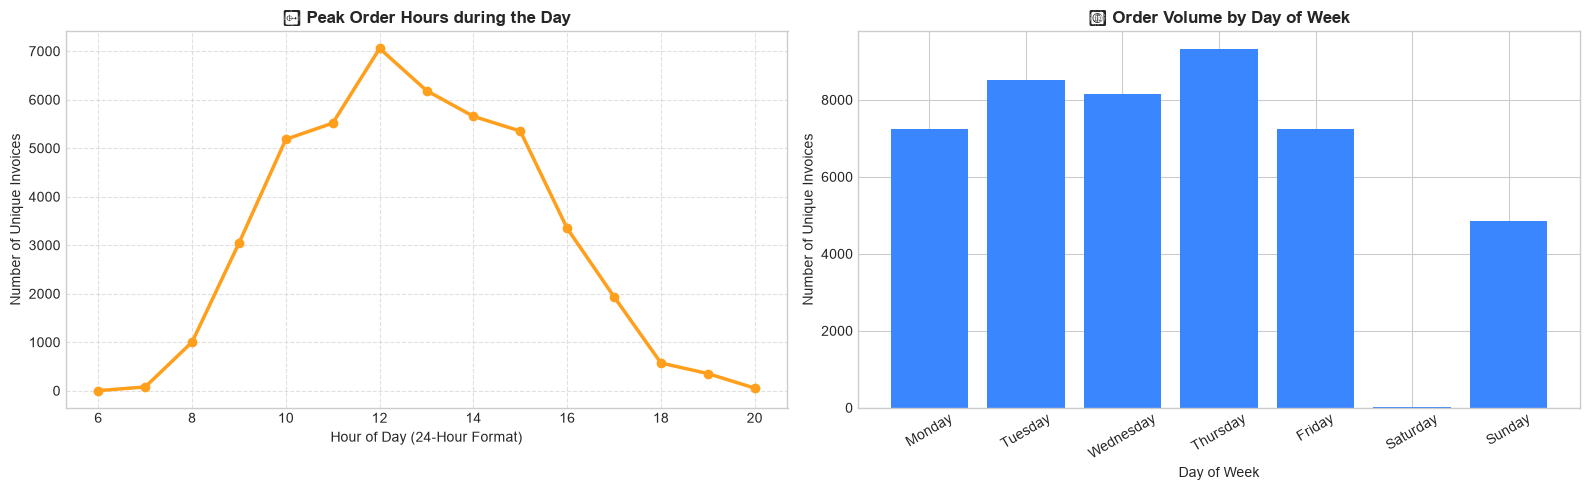

=== ⏰ TIME-SERIES INSIGHTS ===
• Peak Hours: Hour 12:00 (7,056 Invoices)
• Slowest Hours: Hour 6:00 (1 Invoices)
• Busiest Day: Thursday (9,313 Invoices)


In [33]:
# التأكد من تحويل التاريخ
df_valid['InvoiceDate'] = pd.to_datetime(df_valid['InvoiceDate'])

# استخراج الساعة واليوم
df_valid['Hour'] = df_valid['InvoiceDate'].dt.hour
df_valid['DayOfWeek'] = df_valid['InvoiceDate'].dt.day_name()

days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]

hourly_orders = df_valid.groupby('Hour')['Invoice'].nunique()
daily_orders = (
    df_valid.groupby('DayOfWeek')['Invoice']
    .nunique()
    .reindex(days_order)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Peak Hours
axes[0].plot(
    hourly_orders.index,
    hourly_orders.values,
    marker='o',
    color='#ff9f1c',
    linewidth=2.5,
)
axes[0].set_title(
    '⏰ Peak Order Hours during the Day', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Hour of Day (24-Hour Format)')
axes[0].set_ylabel('Number of Unique Invoices')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Daily Trend
axes[1].bar(daily_orders.index, daily_orders.values, color='#3a86ff')
axes[1].set_title(
    '📅 Order Volume by Day of Week', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Unique Invoices')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# طباعة أوقات الذروة
peak_hour = hourly_orders.idxmax()
lowest_hour = hourly_orders.idxmin()
busiest_day = daily_orders.idxmax()

print("=== ⏰ TIME-SERIES INSIGHTS ===")
print(
    f"• Peak Hours: Hour {peak_hour}:00 ({hourly_orders[peak_hour]:,} Invoices)"
)
print(
    f"• Slowest Hours: Hour {lowest_hour}:00 ({hourly_orders[lowest_hour]:,} Invoices)"
)
print(
    f"• Busiest Day: {busiest_day} ({int(daily_orders[busiest_day]):,} Invoices)"
)

## 8. 👤 Customer Entity Aggregation & Baseline RFM Segmentation Profile

### 🎯 Objective:
Aggregate transaction-level records to unique registered customer entities (`Customer ID`) and construct RFM metrics (Recency, Frequency, Monetary) for ML customer segmentation[cite: 19].

### 📊 Baseline RFM Metric Distributions:
* **Entity Universe:** Successfully aggregated **5,881 unique registered customers**[cite: 19, 20].
* **Recency ($R$):** Average inactive duration is **201.46 days** (Median: **96 days**; Range: **1 to 739 days**)[cite: 20].
* **Frequency ($F$):** Average order count is **6.29 unique orders** per customer (Median: **3 orders**; Max: **398 orders**)[cite: 20].
* **Monetary ($M$):** Average customer value is **£3,017.08** (Median: **£897.62**; Max: **£608,821.65**)[cite: 20].
* **Visual Profiling:** Evaluated metric distributions using a **3-panel KDE/Histogram visualization grid** with median markers to establish statistical quantile baseline[cite: 20].

In [34]:
# فلترة العملاء المسجلين فقط للحساب الإحصائي
df_registered = df_valid.dropna(subset=['Customer ID']).copy()

# تاريخ المرجع
snapshot_date = df_registered['InvoiceDate'].max() + pd.Timedelta(days=1)

# تجميع الـ RFM
rfm = (
    df_registered.groupby('Customer ID')
    .agg(
        {
            'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
            'Invoice': 'nunique',
            'TotalPrice': 'sum',
        }
    )
    .reset_index()
)

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

print("=== 👤 REGISTERED CUSTOMERS RFM SUMMARY ===")
print(f"• Total Registered Customers: {len(rfm):,}")
print(rfm.describe().round(2))

rfm.head()

=== 👤 REGISTERED CUSTOMERS RFM SUMMARY ===
• Total Registered Customers: 5,881
       Customer ID  Recency  Frequency   Monetary
count     5881.000 5881.000   5881.000   5881.000
mean     15314.670  201.460      6.290   3017.080
std       1715.430  209.470     13.010  14734.130
min      12346.000    1.000      1.000      0.000
25%      13833.000   26.000      1.000    347.800
50%      15313.000   96.000      3.000    897.620
75%      16797.000  380.000      7.000   2304.180
max      18287.000  739.000    398.000 608821.650


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.460
1,12347,2,8,5633.320
2,12348,75,5,2019.400
3,12349,19,4,4428.690
4,12350,310,1,334.400


C:\Users\LOQ\AppData\Local\Temp\ipykernel_3088\3491045305.py:38: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LOQ\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


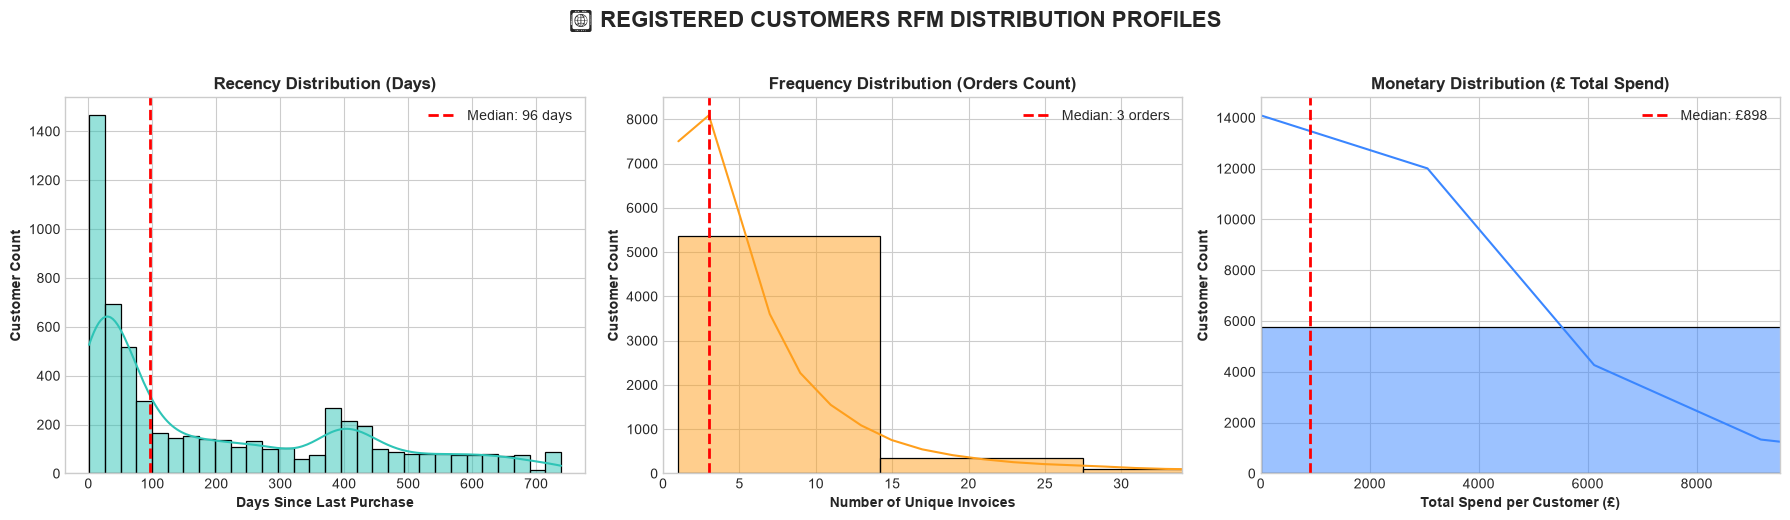

In [35]:
# 1. إنشاء لوحة رسم من 3 أجزاء
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📌 REGISTERED CUSTOMERS RFM DISTRIBUTION PROFILES", fontsize=16, fontweight='bold', y=1.03)

# --- الرسم الأول: Recency Distribution (الأيام منذ آخر شراء) ---
sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='#2ec4b6', bins=30)
axes[0].set_title("Recency Distribution (Days)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Days Since Last Purchase", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Customer Count", fontsize=10, fontweight='bold')
# إضافة خط القيمة المتوسطة (Median)
median_r = rfm['Recency'].median()
axes[0].axvline(median_r, color='red', linestyle='--', linewidth=2, label=f'Median: {median_r:.0f} days')
axes[0].legend()

# --- الرسم الثاني: Frequency Distribution (عدد مرات الشراء) ---
# استخدام Log Scale مرئي أو تحديد حد للمحور لمواجهة الـ Outliers
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='#ff9f1c', bins=30)
axes[1].set_title("Frequency Distribution (Orders Count)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Unique Invoices", fontsize=10, fontweight='bold')
axes[1].set_ylabel("Customer Count", fontsize=10, fontweight='bold')
# تحديد مدى المحور الأفقي لرؤية الكتلة الأساسية للعملاء بوضوح
axes[1].set_xlim(0, np.percentile(rfm['Frequency'], 98))
median_f = rfm['Frequency'].median()
axes[1].axvline(median_f, color='red', linestyle='--', linewidth=2, label=f'Median: {median_f:.0f} orders')
axes[1].legend()

# --- الرسم الثالث: Monetary Distribution (إجمالي الإنفاق للعميل) ---
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='#3a86ff', bins=30)
axes[2].set_title("Monetary Distribution (£ Total Spend)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Total Spend per Customer (£)", fontsize=10, fontweight='bold')
axes[2].set_ylabel("Customer Count", fontsize=10, fontweight='bold')
# تحديد مدى المحور عند الـ 95th percentile لمنع تشتيت الصورة بالقيم الخيالية
axes[2].set_xlim(0, np.percentile(rfm['Monetary'], 95))
median_m = rfm['Monetary'].median()
axes[2].axvline(median_m, color='red', linestyle='--', linewidth=2, label=f'Median: £{median_m:,.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()